In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [ ]:
train_images.shape

(50000, 32, 32, 3)

In [ ]:
from sklearn.model_selection import train_test_split
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.1, random_state=42)

In [ ]:
val_images.shape

(5000, 32, 32, 3)

In [ ]:
test_images.shape

(10000, 32, 32, 3)

In [ ]:
train_images.shape

(45000, 32, 32, 3)

In [ ]:
train_images, test_images, val_images = train_images / 255.0, test_images / 255.0, val_images / 255.0

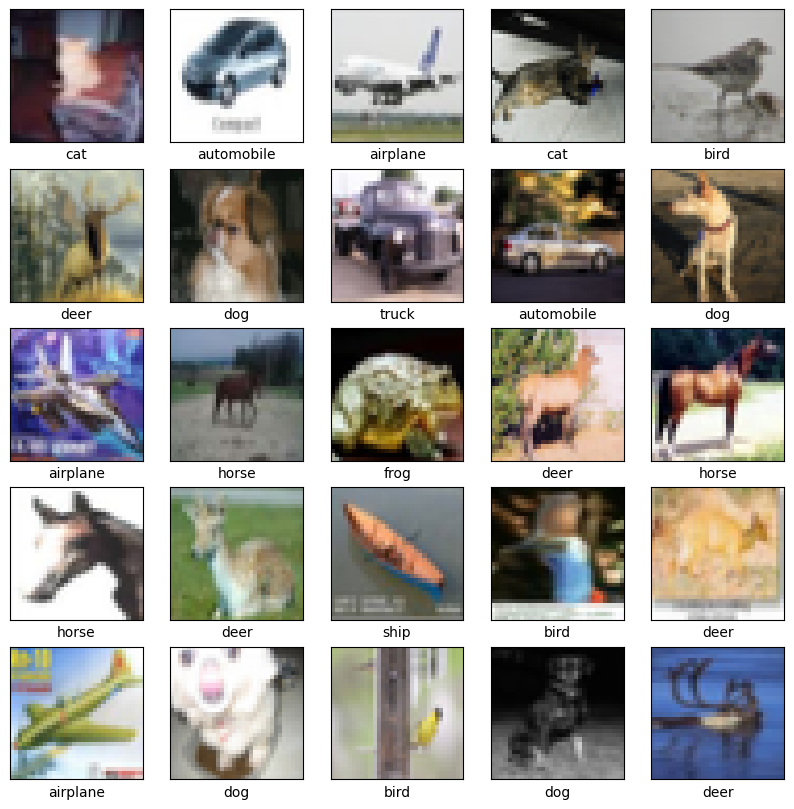

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [ ]:
train_labels = to_categorical(train_labels, 10)
val_labels = to_categorical(val_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9,1.1],
    shear_range=10,
    channel_shift_range=0.1,
)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.0 MB/s eta 0:00:00


In [ ]:
def create_model(trial):
    # Suggest architectural hyperparameters
    n_filters_1 = trial.suggest_categorical('n_filters_1', [32, 64])
    n_filters_2 = trial.suggest_categorical('n_filters_2', [64, 128])
    n_filters_3 = trial.suggest_categorical('n_filters_3', [128, 256])

    fc_units = trial.suggest_int('fc_units', 256, 512, step=128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.5)

    # Suggest optimizer hyperparameters
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])

    model = models.Sequential([
        # Block 1 (32x32 -> 16x16)
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(n_filters_1, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(n_filters_1, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Block 2 (16x16 -> 8x8)
        layers.Conv2D(n_filters_2, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(n_filters_2, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 3 (8x8 -> 4x4)
        layers.Conv2D(n_filters_3, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Classifier Head
        layers.Flatten(),
        layers.Dense(fc_units, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy', #labels are one-hot encoded
        metrics=['accuracy']
    )

    return model

In [ ]:
def objective(trial):
    model = create_model(trial)

    batch_size = trial.suggest_categorical('batch_size', [64, 128])

    epochs = 10

    history = model.fit(
        train_images, train_labels,
        validation_data=(val_images, val_labels),
        batch_size=batch_size,
        epochs=epochs,
        verbose=0
    )

    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy

In [ ]:
import optuna
if __name__ == '__main__':
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    print(" Best Trial Results ")
    trial = study.best_trial
    print(f"  Best Validation Accuracy: {trial.value:.4f}")
    print("  Best Hyperparameters:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

[I 2026-08-15 17:51:26,767] A new study created in memory with name: no-name-40726d6c-cb1f-4c88-b9ba-4b66d91eab8a
[I 2026-08-15 17:53:11,465] Trial 0 finished with value: 0.8361999988555908 and parameters: {'n_filters_1': 32, 'n_filters_2': 128, 'n_filters_3': 256, 'fc_units': 256, 'dropout_rate': 0.3797120782938262, 'lr': 0.004578921515476851, 'optimizer': 'adam', 'batch_size': 64}. Best is trial 0 with value: 0.8361999988555908.
[I 2026-08-15 17:54:38,107] Trial 1 finished with value: 0.807200014591217 and parameters: {'n_filters_1': 32, 'n_filters_2': 128, 'n_filters_3': 128, 'fc_units': 384, 'dropout_rate': 0.3734670150687526, 'lr': 0.008960894095809125, 'optimizer': 'rmsprop', 'batch_size': 128}. Best is trial 0 with value: 0.8361999988555908.
[I 2026-08-15 17:56:41,423] Trial 2 finished with value: 0.7757999897003174 and parameters: {'n_filters_1': 64, 'n_filters_2': 128, 'n_filters_3': 256, 'fc_units': 384, 'dropout_rate': 0.34405505581631685, 'lr': 0.0005842742385821616, 'optim

 Best Trial Results 
  Best Validation Accuracy: 0.8362
  Best Hyperparameters:
    n_filters_1: 32
    n_filters_2: 128
    n_filters_3: 256
    fc_units: 256
    dropout_rate: 0.3797120782938262
    lr: 0.004578921515476851
    optimizer: adam
    batch_size: 64


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Rebuild the model using best hyperparameters
best_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3797),
    layers.Dense(10, activation='softmax')
])

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.004579),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = best_model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    batch_size=64,
    epochs=40,
    verbose=1
)

test_loss, test_acc = best_model.evaluate(test_images, test_labels)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.5134 - loss: 1.3558 - val_accuracy: 0.5190 - val_loss: 1.4488
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6703 - loss: 0.9377 - val_accuracy: 0.6036 - val_loss: 1.1721
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7201 - loss: 0.8065 - val_accuracy: 0.5586 - val_loss: 1.4061
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7509 - loss: 0.7201 - val_accuracy: 0.6394 - val_loss: 1.0166
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7701 - loss: 0.6594 - val_accuracy: 0.7716 - val_loss: 0.6585
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7902 - loss: 0.6066 - val_accuracy: 0.7414 - val_loss: 0.7491
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8051 - loss: 0.5665 - val_accuracy: 0.7834 - val_loss: 0.6279
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8193 - loss: 0.5249 - val_ac

In [ ]:
best_model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_71 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_71 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_72 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 16, 16, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_73 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_74 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_75 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,630,528 (17.66 MB)

 Trainable params: 1,542,954 (5.89 MB)

 Non-trainable params: 1,664 (6.50 KB)

 Optimizer params: 3,085,910 (11.77 MB)

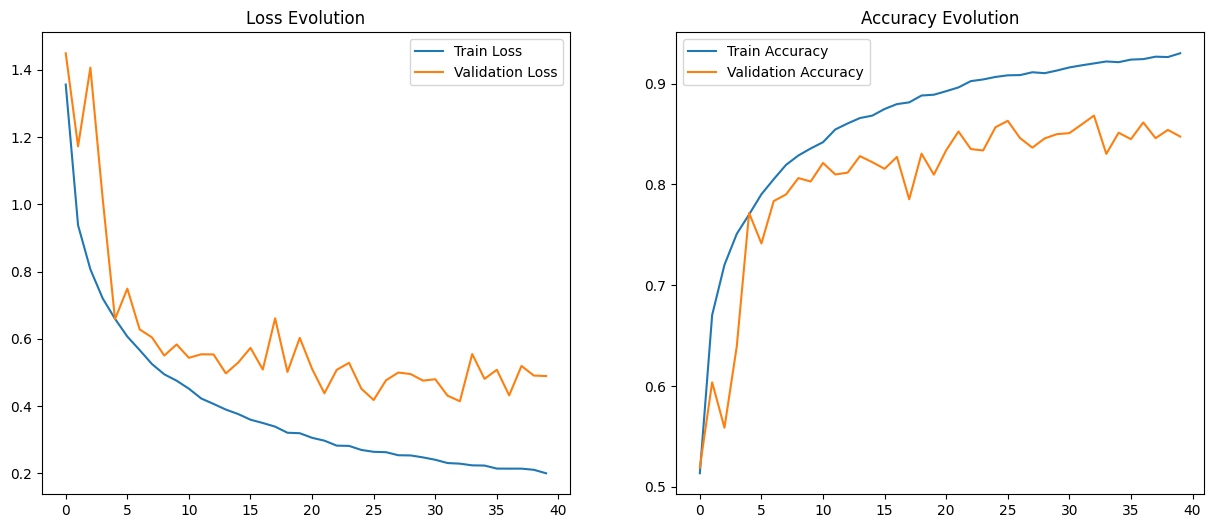

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
plt.plot(best_model.history.history['loss'], label='Train Loss')
plt.plot(best_model.history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(1, 2, 2)
plt.plot(best_model.history.history['accuracy'], label='Train Accuracy')
plt.plot(best_model.history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

# trying another model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_scratch_cnn():
    inputs = layers.Input(shape=(32, 32, 3))

    # Block 1: Feature Extraction
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Drops to 16x16
    x = layers.Dropout(0.2)(x)

    # Block 2: Intermediate Features with Residual Connection (16x16) ---
    # Saving shortcut for residual connection
    shortcut = layers.Conv2D(128, (1, 1), strides=(1, 1), padding='same')(x)

    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Add residual shortcut back
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Drops to 8x8
    x = layers.Dropout(0.3)(x)

    # Block 3
    shortcut = layers.Conv2D(256, (1, 1), strides=(1, 1), padding='same')(x)

    x = layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Drops to 4x4
    x = layers.Dropout(0.4)(x)

    # Classifier Head
    x = layers.GlobalAveragePooling2D()(x) # Averages 4x4 spatial dimensions to prevent massive dense layers
    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Scratch_CNN")
    return model

model2 = build_scratch_cnn()

In [ ]:
model2.summary()

Model: "Scratch_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_22[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_92[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_88       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 32, 32,    │     36,928 │ activation_88[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_93[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_89       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_58    │ (None, 16, 16,    │          0 │ activation_89[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_64          │ (None, 16, 16,    │          0 │ max_pooling2d_58… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 16, 16,    │     73,856 │ dropout_64[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_90       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 16, 16,    │    147,584 │ activation_90[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 16, 16,    │      8,320 │ dropout_64[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │ conv2d_94[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_91       │ (None, 16, 16,    │          0 │ add_4[0][0]     

 Total params: 1,329,098 (5.07 MB)

 Trainable params: 1,326,282 (5.06 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model2.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    batch_size=64,
    epochs=40,
    verbose=1
)

test_loss, test_acc = model2.evaluate(test_images, test_labels)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.4340 - loss: 1.6240 - val_accuracy: 0.4992 - val_loss: 1.4112
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6258 - loss: 1.0462 - val_accuracy: 0.5418 - val_loss: 1.4357
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7024 - loss: 0.8437 - val_accuracy: 0.7204 - val_loss: 0.7916
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7488 - loss: 0.7171 - val_accuracy: 0.7268 - val_loss: 0.7784
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7808 - loss: 0.6315 - val_accuracy: 0.7954 - val_loss: 0.5965
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8052 - loss: 0.5664 - val_accuracy: 0.7742 - val_loss: 0.6600
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8221 - loss: 0.5150 - val_accuracy: 0.8010 - val_loss: 0.5807
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8359 - loss: 0.4744 - 

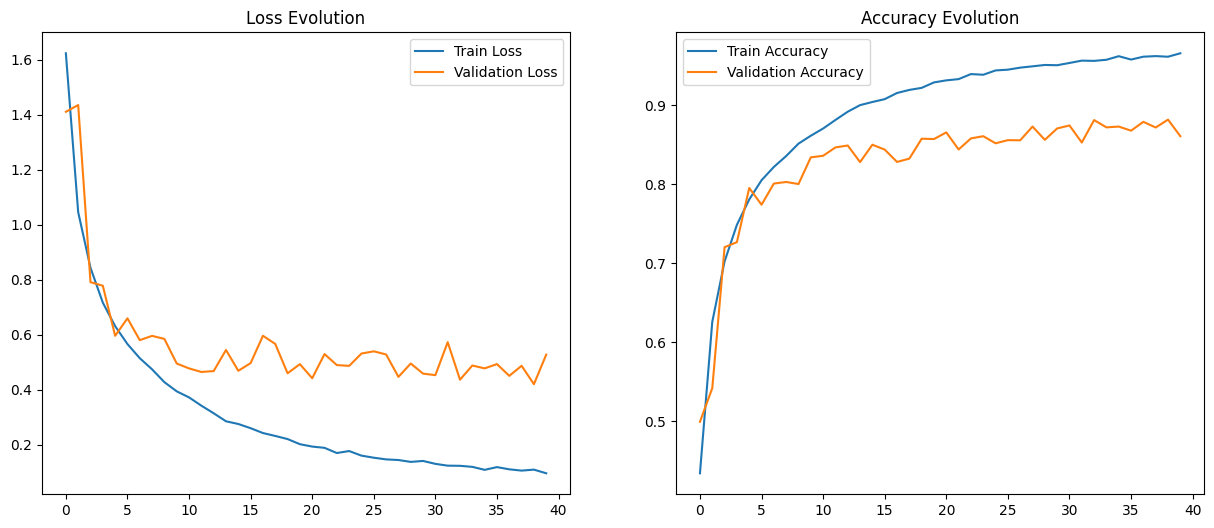

In [ ]:
plt.figure(figsize=(15,6))

plt.subplot(1, 2, 1)
plt.plot(model2.history.history['loss'], label='Train Loss')
plt.plot(model2.history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Evolution')

plt.subplot(1, 2, 2)
plt.plot(model2.history.history['accuracy'], label='Train Accuracy')
plt.plot(model2.history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()